## Config laden & Init

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import seaborn as sns
import os

from sklearn.feature_selection import SelectKBest, f_regression, RFE, mutual_info_regression
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from mrmr import mrmr_regression
from pathlib import Path
from typing import cast

# Load Constants
NB_PATH = Path(globals()["__vsc_ipynb_file__"]).resolve()
ROOT = NB_PATH.parent.parent 
FIG_PATH = ROOT / "reports" / "figures"
CONFIG_PATH = ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

CSV_PATH = ROOT / config["data"]["csv_path"]

# Initialisierung
rs = config["modeling"]["random_state"]
np.random.seed(rs)
dpi = config["modeling"]["dpi"]
df = pd.read_csv(CSV_PATH, sep=config["data"]["sep"])
figsize = config["modeling"]["figsize"]
blue_color = config["modeling"]["blue_color"]
default_color = config["modeling"]["default_color"]


# Init Plot
def save_plot(fig, title, save_path=FIG_PATH):
    filename = f"{title}.png"
    filepath = os.path.join(save_path, filename)
    fig.savefig(filepath, bbox_inches="tight", dpi=dpi)

def get_color_series(index, highlight_features, highlight_color=blue_color, default_color=default_color):
    return [highlight_color if feature in highlight_features else default_color for feature in index]

## Feature Selection: Mutual Information

100%|██████████| 10/10 [00:00<00:00, 73.72it/s]


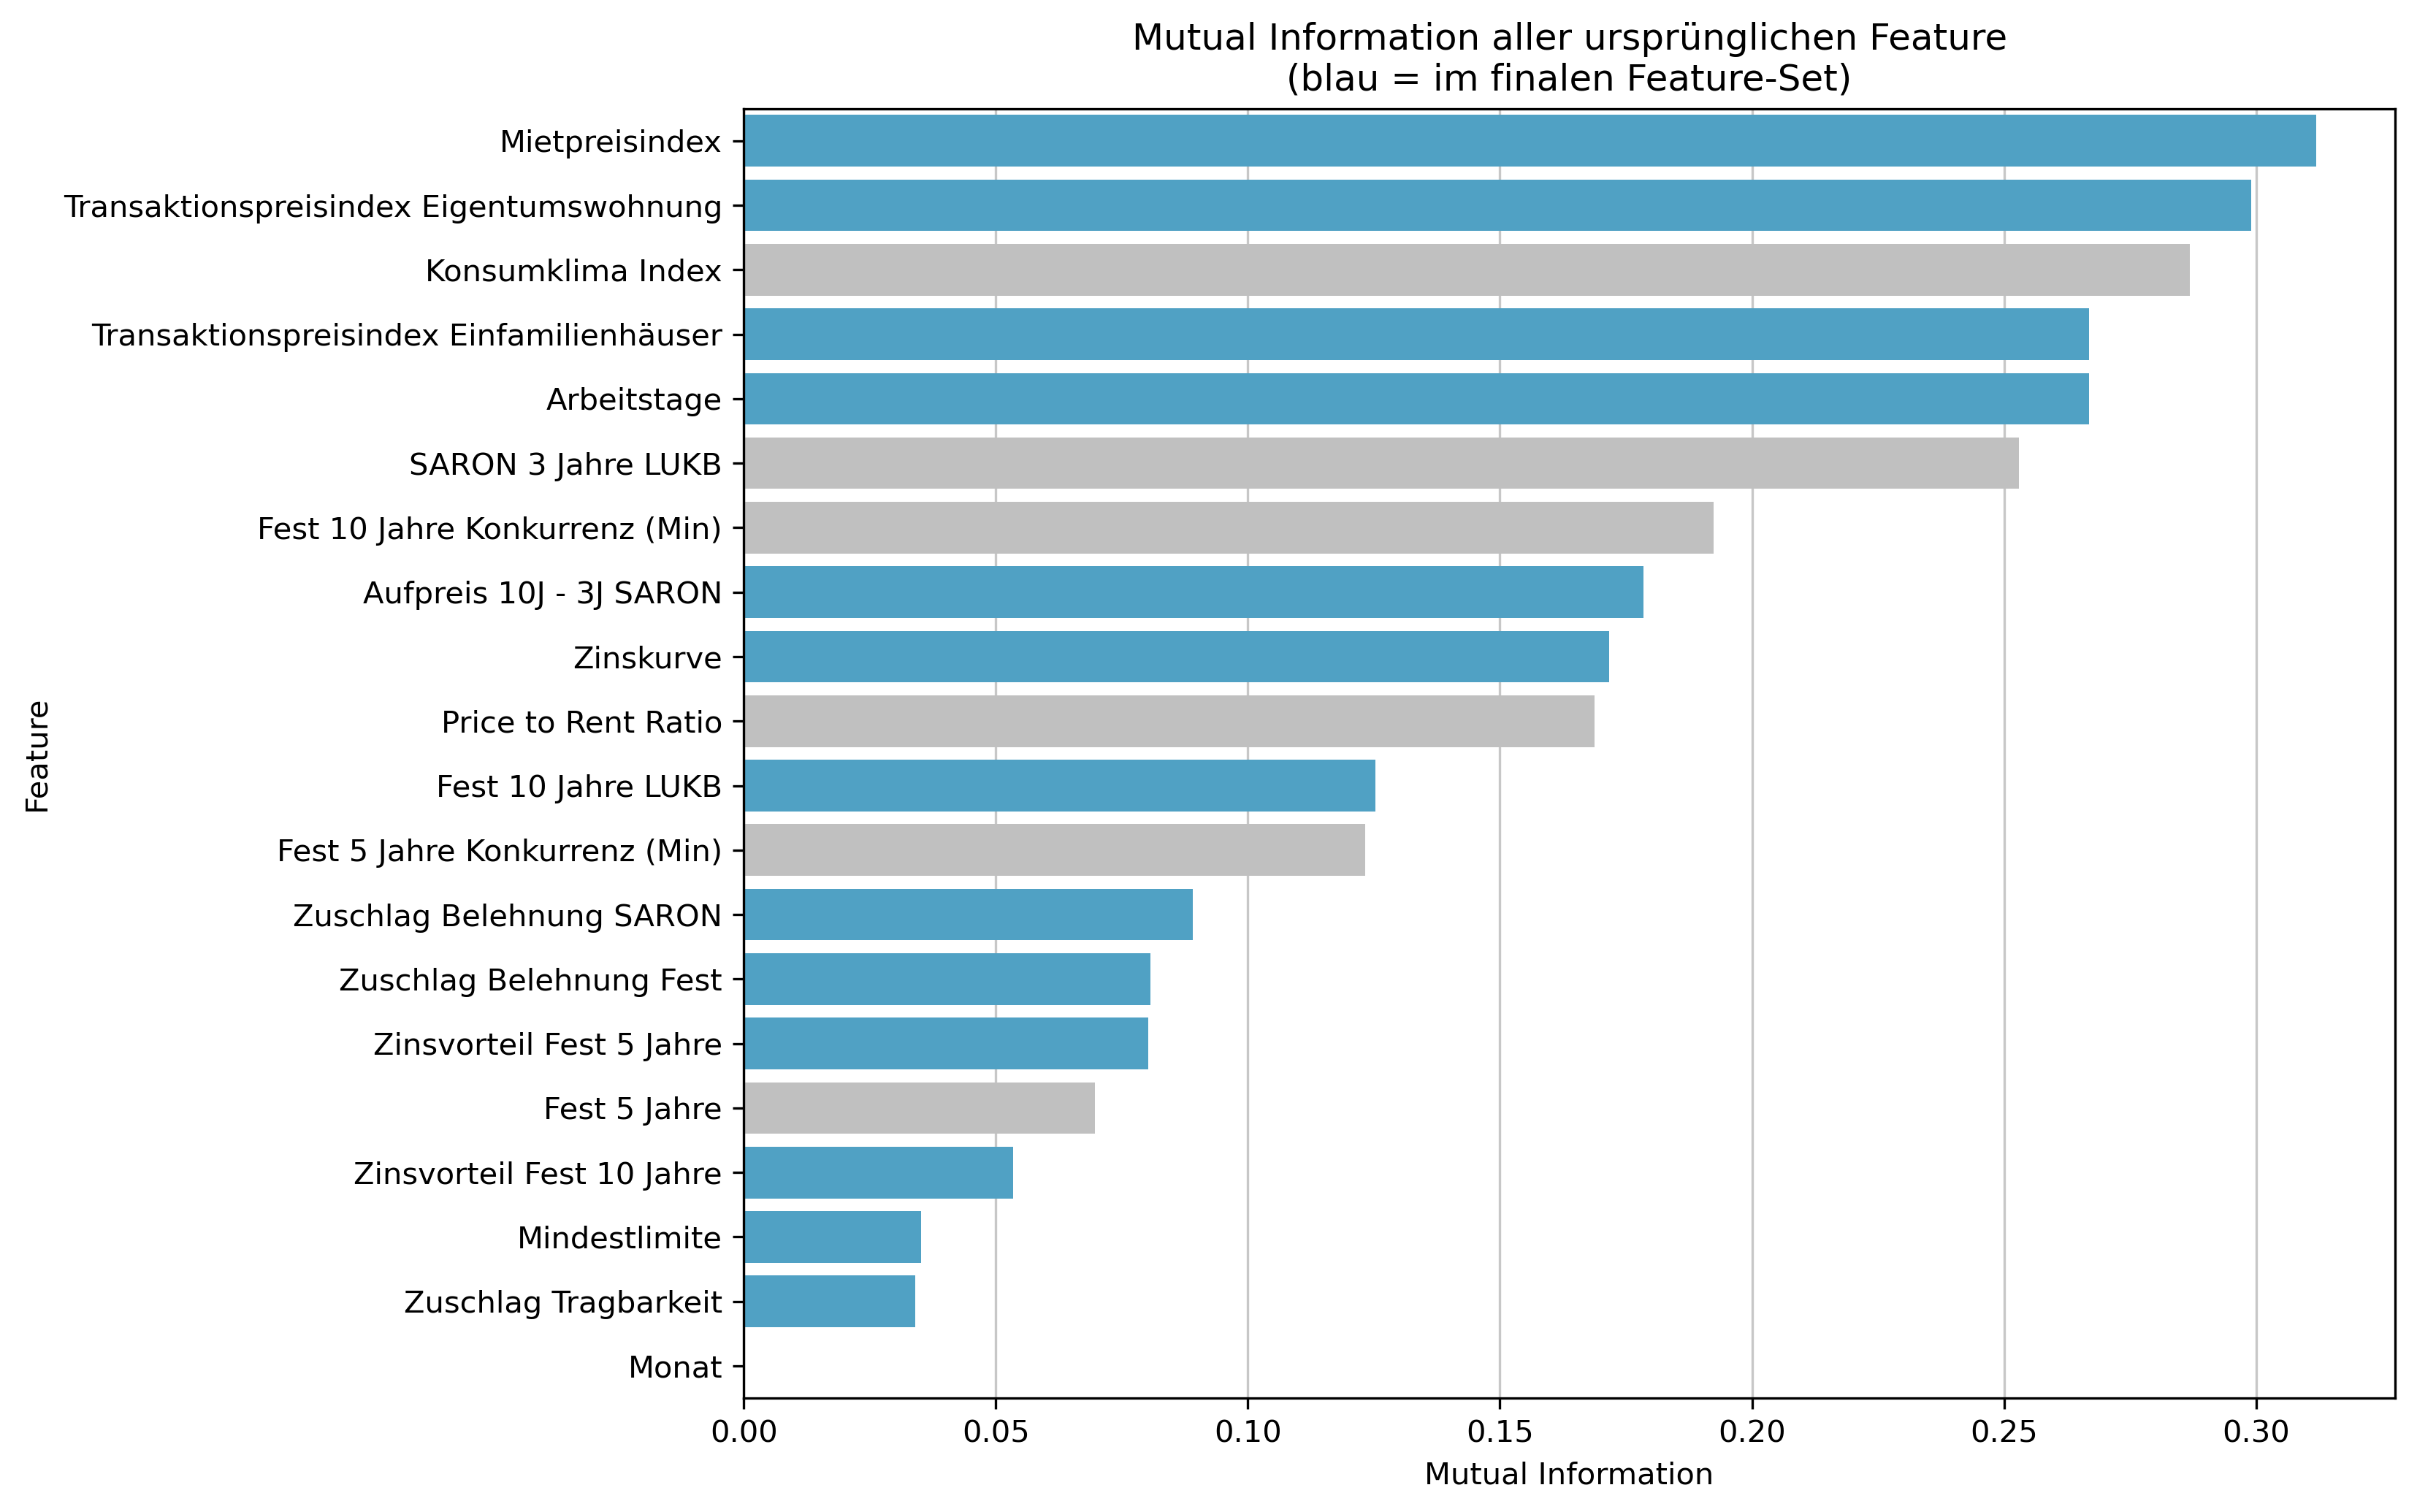

Ursprünglich verfügbare Feature:
['Zuschlag Belehnung SARON', 'Zuschlag Belehnung Fest', 'Zuschlag Tragbarkeit', 'Mindestlimite', 'Arbeitstage', 'Fest 10 Jahre LUKB', 'Fest 10 Jahre Konkurrenz (Min)', 'Zinsvorteil Fest 10 Jahre', 'Fest 5 Jahre', 'Fest 5 Jahre Konkurrenz (Min)', 'Zinsvorteil Fest 5 Jahre', 'Zinskurve', 'Price to Rent Ratio', 'Transaktionspreisindex Einfamilienhäuser', 'SARON 3 Jahre LUKB', 'Aufpreis 10J - 3J SARON', 'Mietpreisindex', 'Konsumklima Index', 'Transaktionspreisindex Eigentumswohnung', 'Monat'] 

Vom mRMR-Verfahren ausgewählte Feature:
['Transaktionspreisindex Eigentumswohnung', 'Arbeitstage', 'Mietpreisindex', 'Transaktionspreisindex Einfamilienhäuser', 'Mindestlimite', 'Zinskurve', 'Zinsvorteil Fest 5 Jahre', 'Aufpreis 10J - 3J SARON', 'Fest 10 Jahre LUKB', 'Zinsvorteil Fest 10 Jahre'] 

Finale Auswahl nach mRMR + Stakeholder-Input:
['Zinskurve', 'Transaktionspreisindex Eigentumswohnung', 'Mietpreisindex', 'Zinsvorteil Fest 5 Jahre', 'Fest 10 Jahre LUKB', '

In [64]:
# Initialisierung
scaler = StandardScaler()

# Daten laden und vorbereiten
df["Datum"] = pd.to_datetime(df["Datum"], format="%d.%m.%y", errors="coerce")
df["Monat"] = df["Datum"].dt.month
df.drop(columns=["Datum", "Woche", "Abschluss Broker Neu", "Abschluss Broker Ablösung", 
                 "Abschluss Swissquote Neu", "Abschluss Swissquote Ablösung"], inplace=True)

# Zielvariable und Feature-Matrix
target = "Alle Abschlüsse"
X_full = df.drop(columns=[target])
y = df[target]

# Stakeholder-relevante Feature
stakeholder_features = [
    "Zuschlag Belehnung SARON",
    "Zuschlag Tragbarkeit",
    "Zuschlag Belehnung Fest",
    "Mindestlimite"
]

# mRMR: Auswahl der 10 informativsten und möglichst unabhängigen Feature
selected_mrmr = cast(list[str], mrmr_regression(X=X_full, y=y, K=10))

# Kombination mit Stakeholder-Input
selected_features = list(set(selected_mrmr).union(stakeholder_features))

X = X_full[selected_features]
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
feature_names = X.columns.tolist()

# Mutual Information für alle ursprünglichen Feature
mi_all = mutual_info_regression(X_full, y, random_state=rs)
mi_all_series = pd.Series(mi_all, index=X_full.columns).sort_values(ascending=False)
mi_all_df = pd.DataFrame({
    "Mutual Information": mi_all_series,
    "Im finalen Set": [1 if f in selected_features else 0 for f in mi_all_series.index]
})

# Farbzuweisung für Plot
colors = [blue_color if f in selected_features else default_color for f in mi_all_series.index]

plt.figure(figsize=(11.13, 7), dpi=dpi)
ax = sns.barplot(
    x=mi_all_series.values,
    y=mi_all_series.index,
    palette=colors
)

# Plot-Layout
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='-', alpha=0.7)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information aller ursprünglichen Feature\n(blau = im finalen Feature-Set)")
plt.tight_layout()
plt.show()

# SelectKBest (F-Test)
selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X, y)

selector.scores_ = np.asarray(selector.scores_, dtype=float).ravel()
f_scores = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)

# RFE (Recursive Feature Elimination)
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_scaled, y)
rfe_ranking = pd.Series(rfe.ranking_, index=feature_names).sort_values()

# Lasso-Regression (L1-Regularisierung)
lasso = LassoCV(cv=5, random_state=rs, max_iter=20000)
lasso.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
lasso_coefs_nonzero = lasso_coefs[lasso_coefs.abs() > 1e-5].sort_values(key=np.abs, ascending=False)

# Random Forest Feature Importance
forest = RandomForestRegressor(n_estimators=1000, random_state=rs)
forest.fit(X, y)
rf_importances = pd.Series(forest.feature_importances_, index=feature_names).sort_values(ascending=False)

# Zusammenfassung
print("Ursprünglich verfügbare Feature:")
print(X_full.columns.tolist(), "\n")

print("Vom mRMR-Verfahren ausgewählte Feature:")
print(selected_mrmr, "\n")

print("Finale Auswahl nach mRMR + Stakeholder-Input:")
print(selected_features)


## Feature-Selection pro Methode

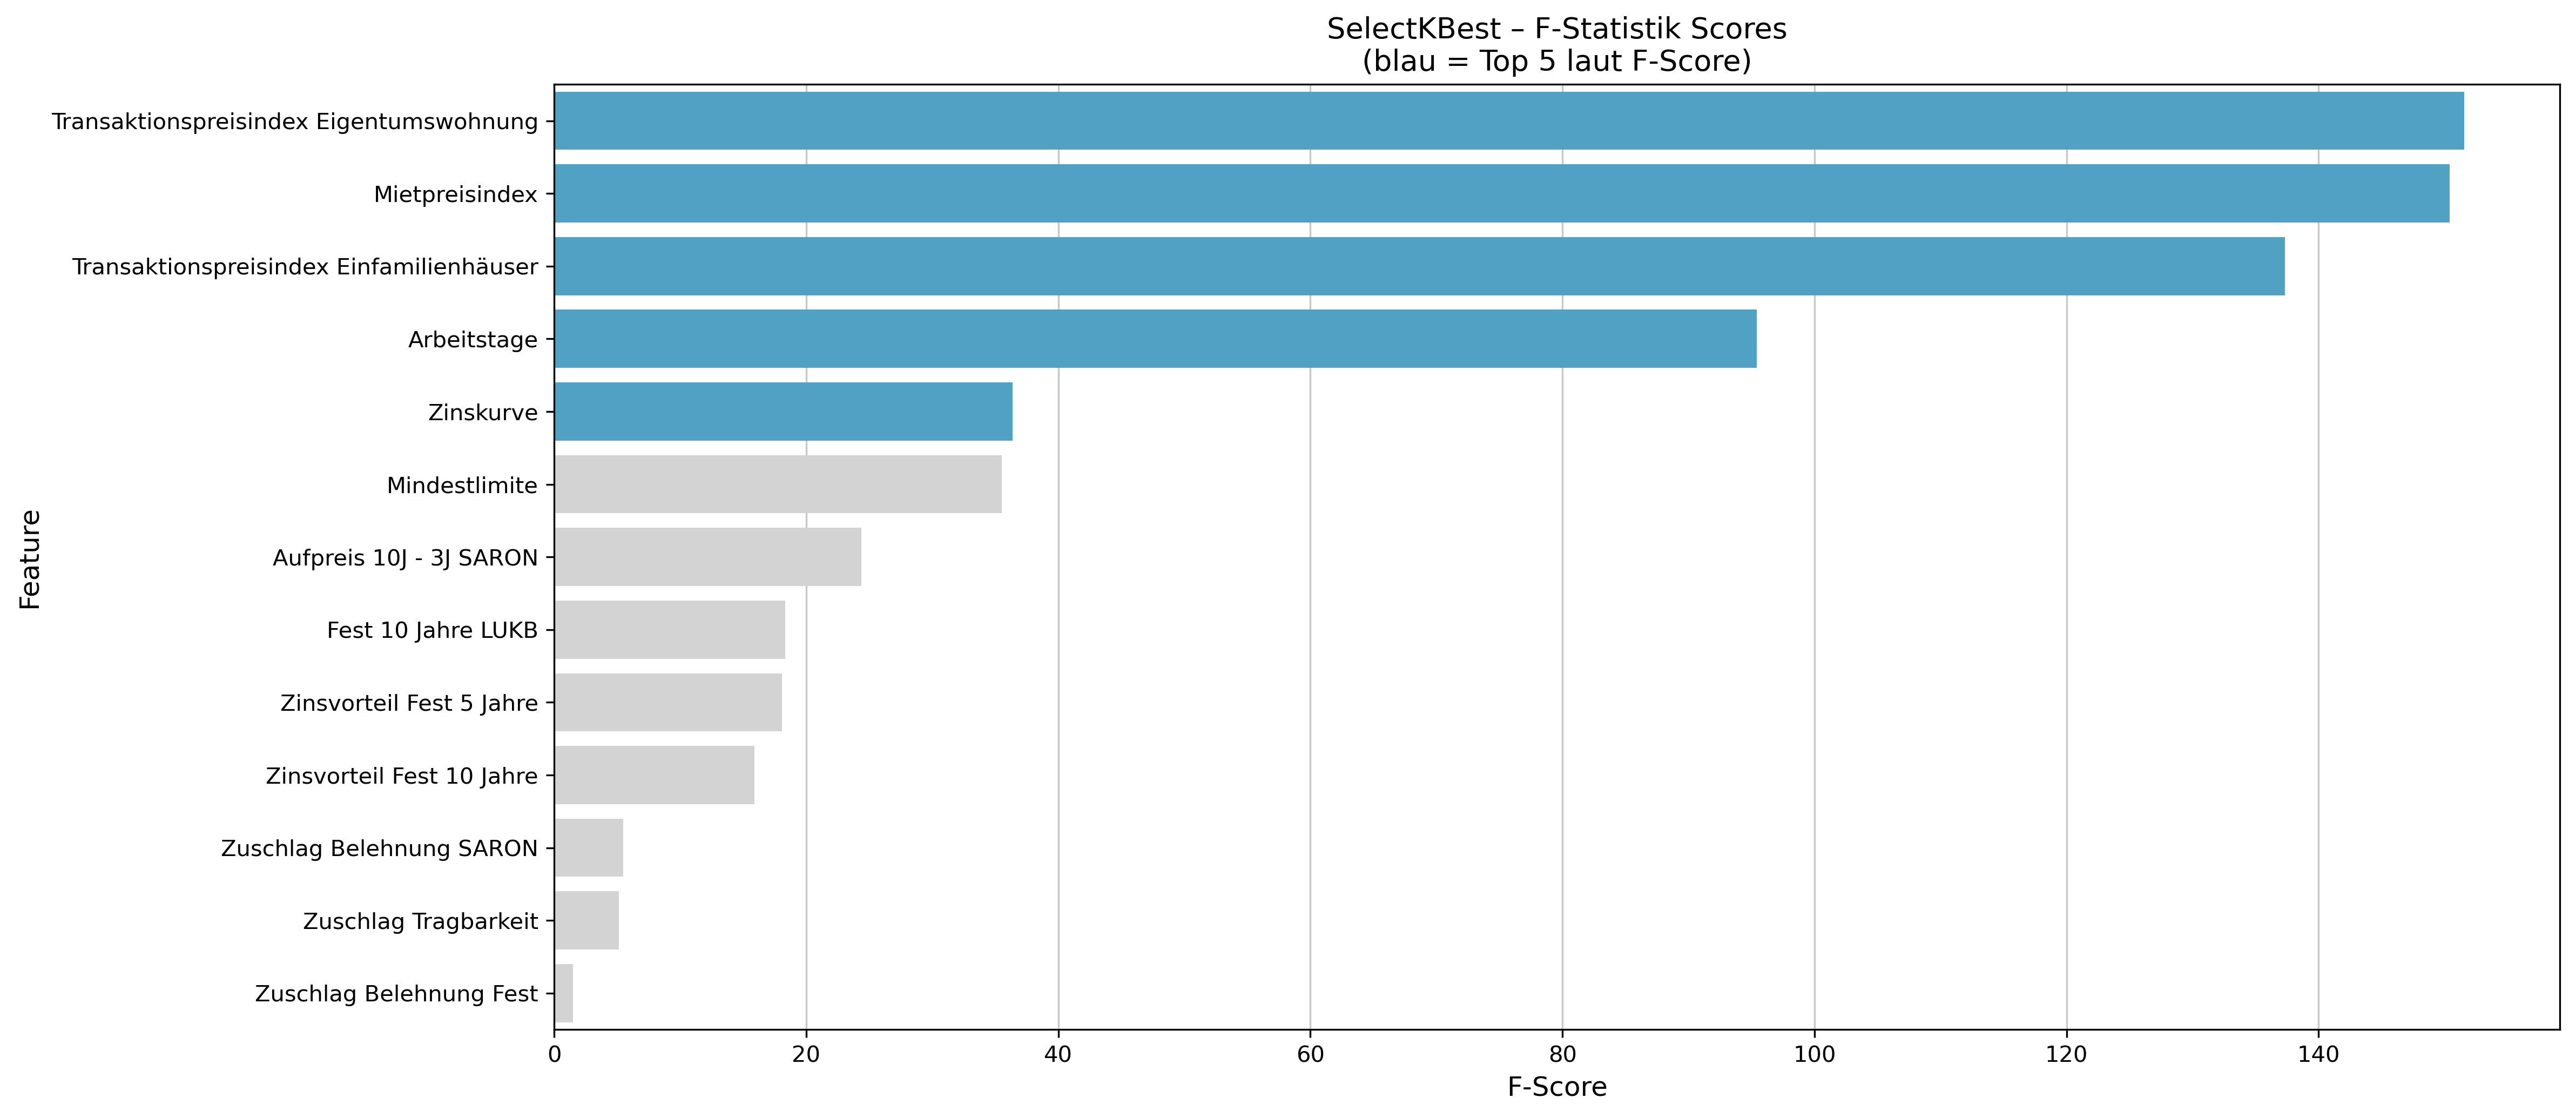

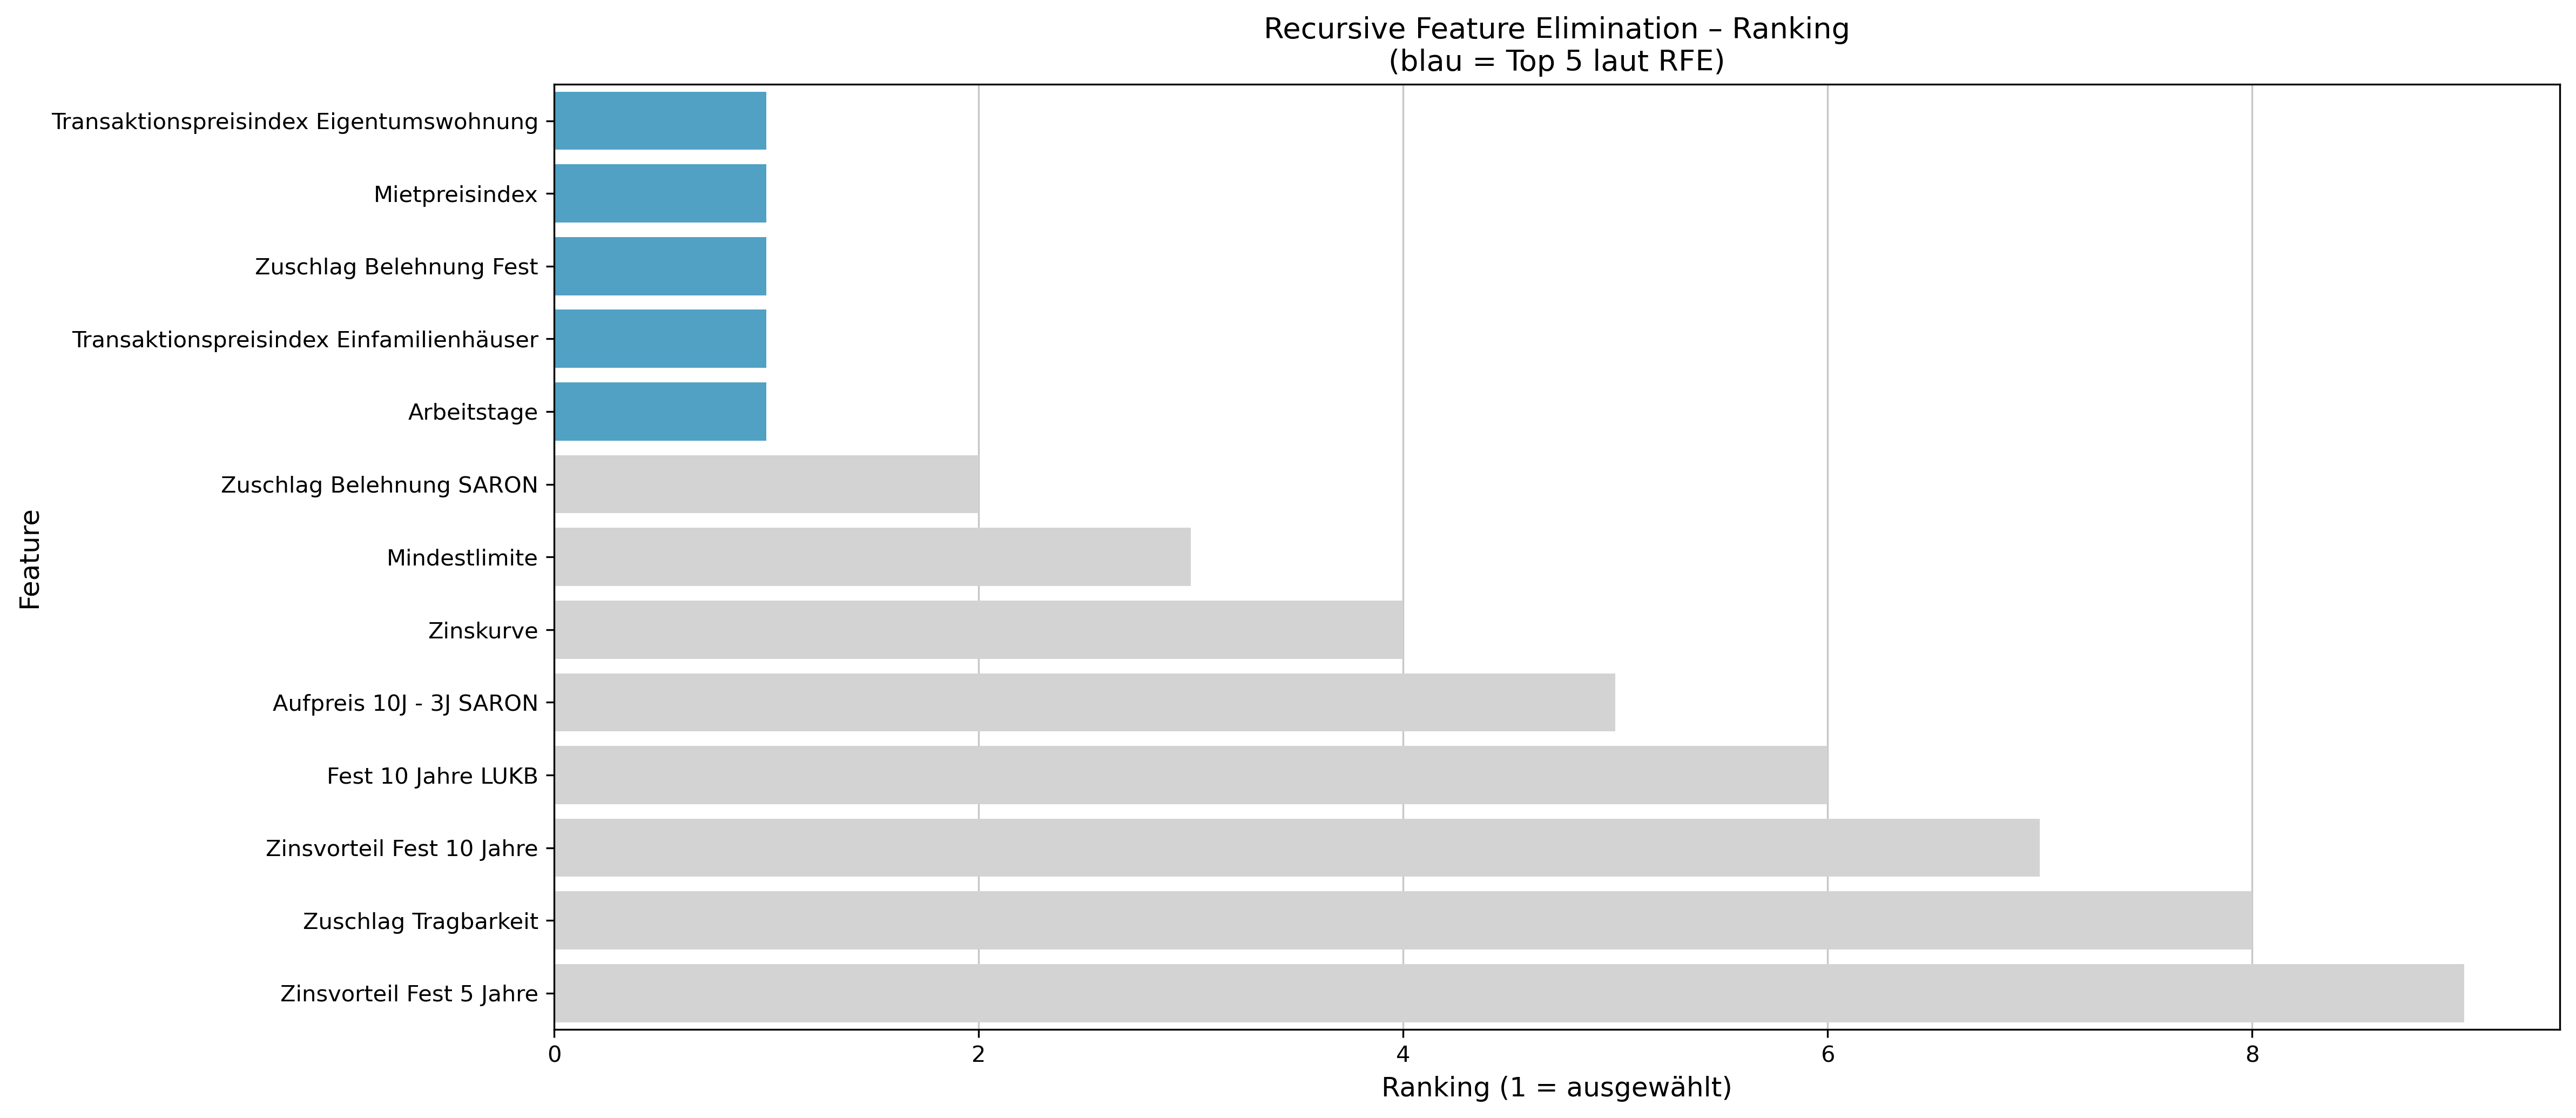

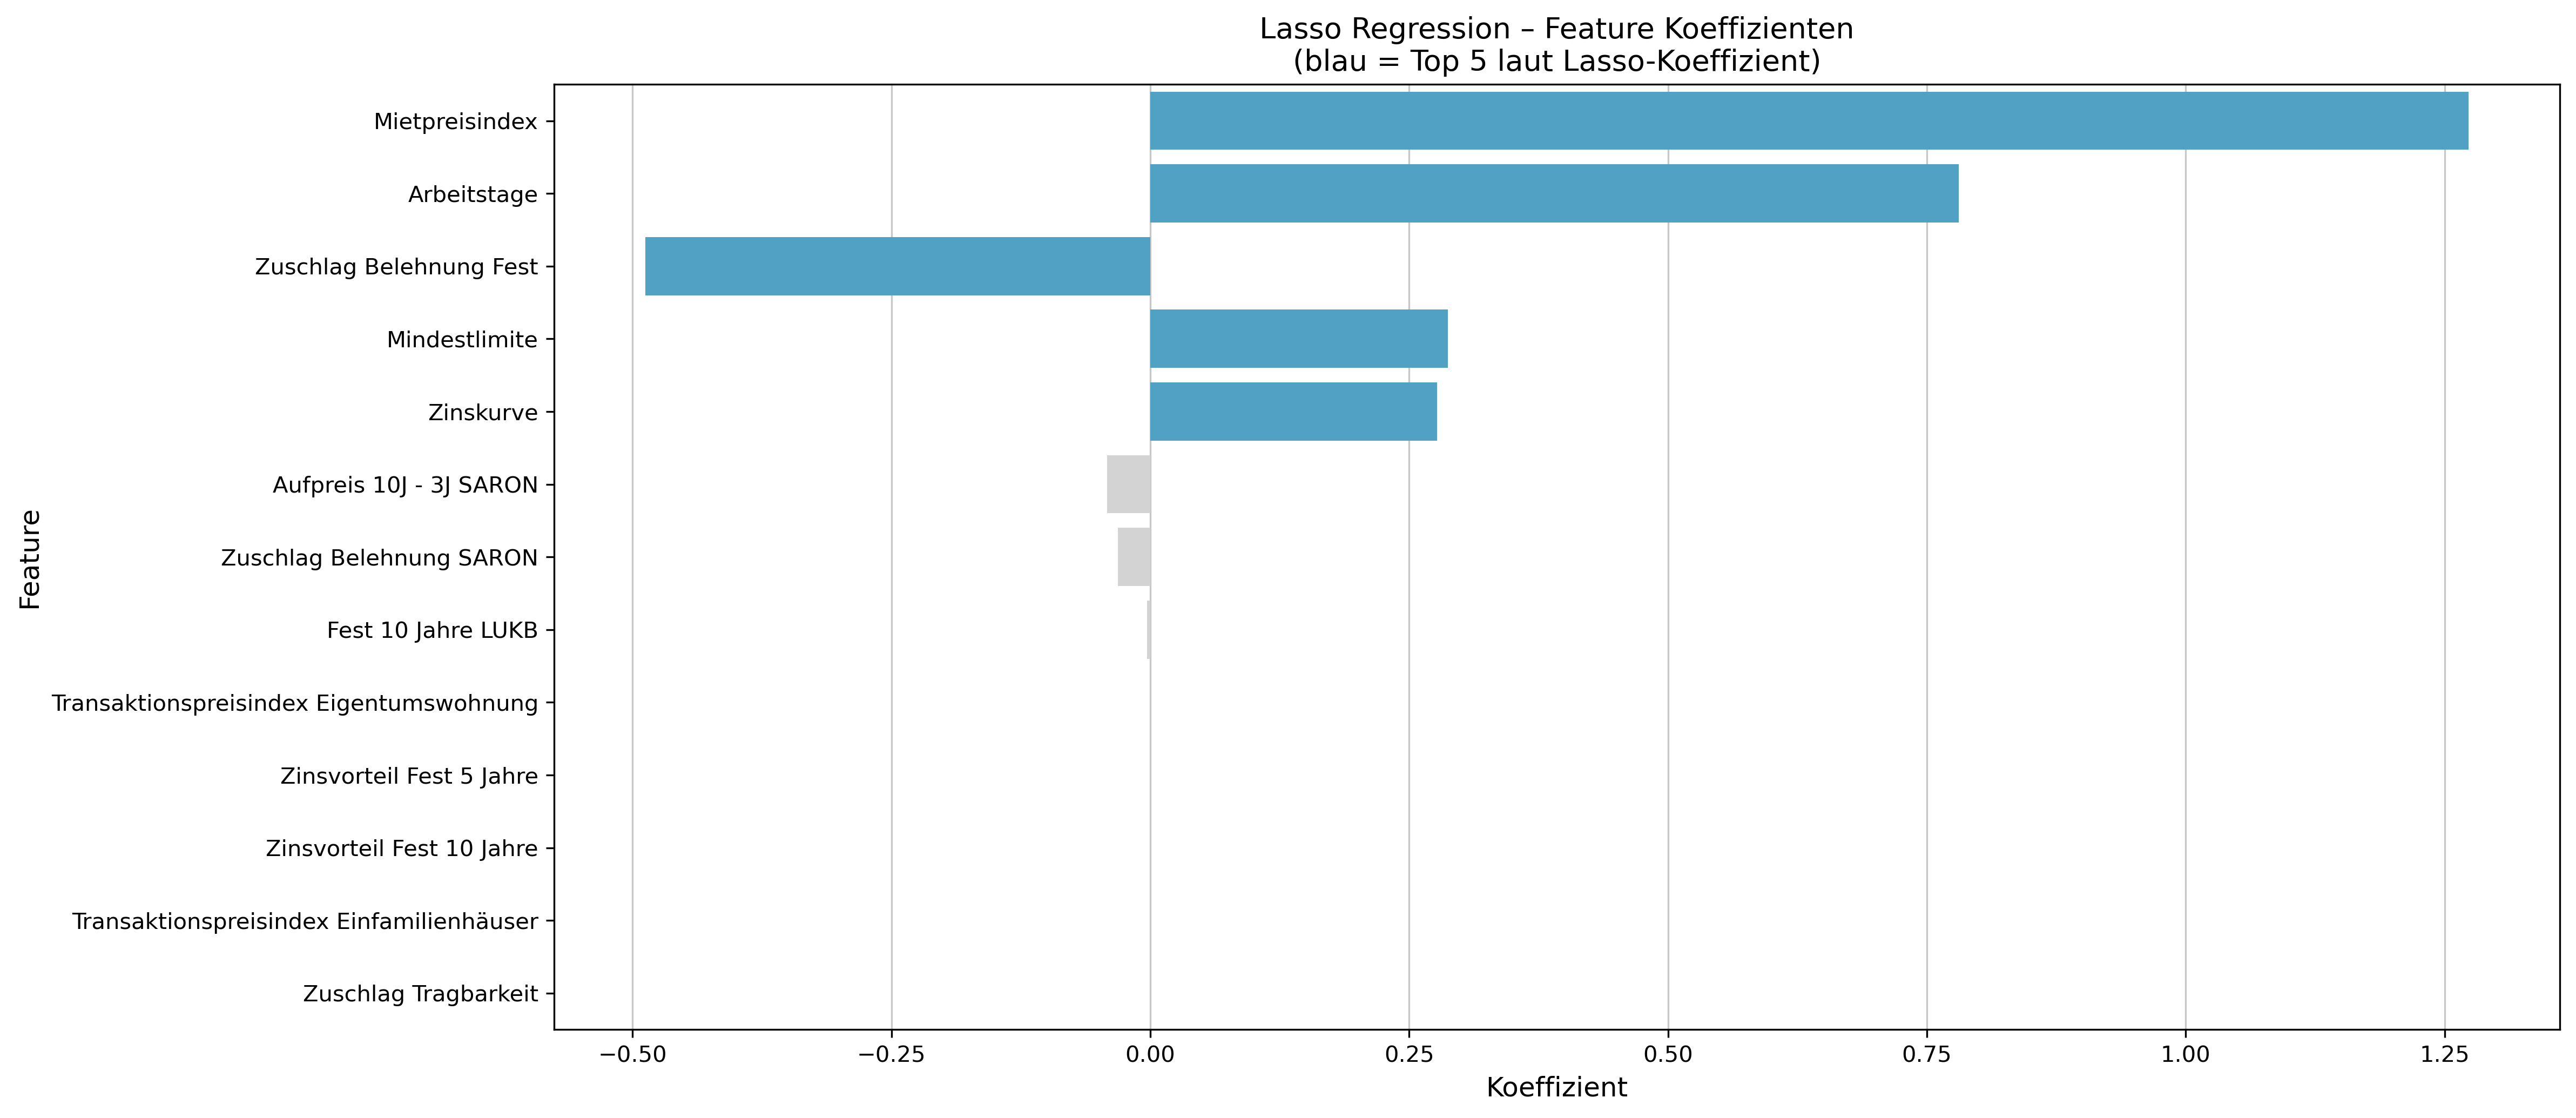

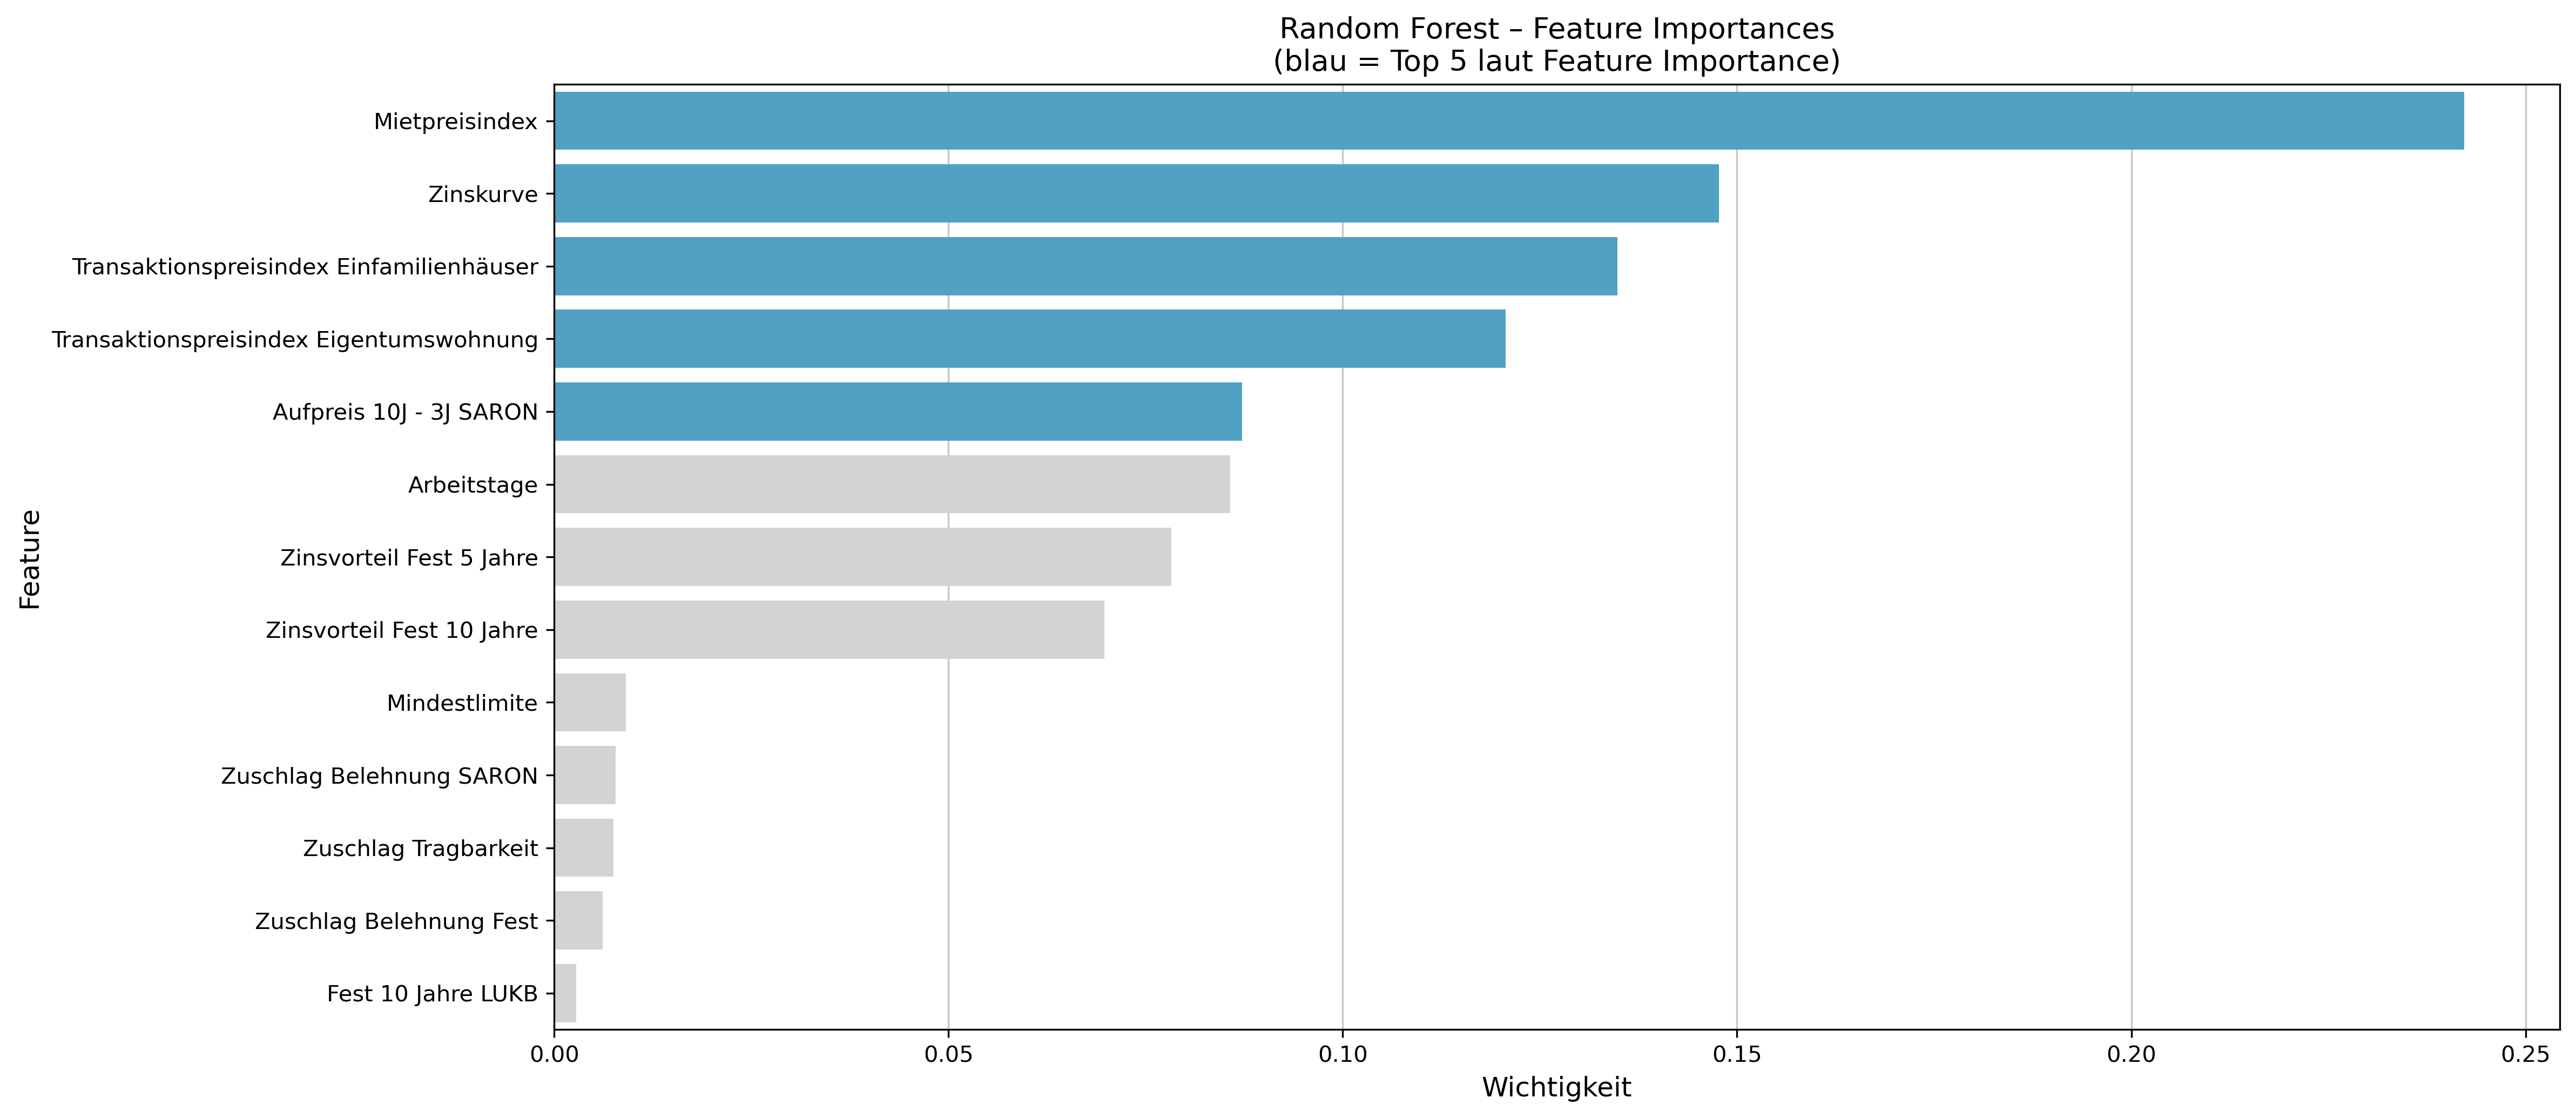

In [66]:
# SelectKBest
top5_skb = f_scores.sort_values(ascending=False).head(5).index.tolist()
f_scores_full = f_scores.reindex(feature_names).fillna(0).sort_values(ascending=False)
colors = get_color_series(f_scores_full.index, top5_skb)

title = "SelectKBest – F-Statistik Scores"
plt.figure(figsize=figsize, dpi=dpi)
ax = sns.barplot(x=f_scores_full.values, y=f_scores_full.index, palette=colors)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='-', alpha=0.7)
plt.title(title + "\n(blau = Top 5 laut F-Score)", fontsize=13)
plt.xlabel("F-Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
save_plot(plt.gcf(), title)
plt.show()

# RFE
top5_rfe = rfe_ranking[rfe_ranking == 1].head(5).index.tolist()
rfe_ranking_full = rfe_ranking.reindex(feature_names).fillna(rfe_ranking.max() + 1).sort_values()
colors = get_color_series(rfe_ranking_full.index, top5_rfe)

title = "Recursive Feature Elimination – Ranking"
plt.figure(figsize=figsize, dpi=dpi)
ax = sns.barplot(x=rfe_ranking_full.values, y=rfe_ranking_full.index, palette=colors)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='-', alpha=0.7)
plt.title(title + "\n(blau = Top 5 laut RFE)", fontsize=13)
plt.xlabel("Ranking (1 = ausgewählt)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
save_plot(plt.gcf(), title)
plt.show()

# Lasso Regression
lasso_nonzero = lasso_coefs[lasso_coefs.abs() > 1e-5]
top5_lasso = lasso_nonzero.abs().sort_values(ascending=False).head(5).index.tolist()
lasso_all_coefs = lasso_coefs.reindex(feature_names).fillna(0).sort_values(key=lambda x: abs(x), ascending=False)
colors = get_color_series(lasso_all_coefs.index, top5_lasso)

title = "Lasso Regression – Feature Koeffizienten"
plt.figure(figsize=figsize, dpi=dpi)
ax = sns.barplot(x=lasso_all_coefs.values, y=lasso_all_coefs.index, palette=colors)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='-', alpha=0.7)
plt.title(title + "\n(blau = Top 5 laut Lasso-Koeffizient)", fontsize=13)
plt.xlabel("Koeffizient", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
save_plot(plt.gcf(), title)
plt.show()

# Random Forest
top5_rf = rf_importances.sort_values(ascending=False).head(5).index.tolist()
rf_full = rf_importances.reindex(feature_names).fillna(0).sort_values(ascending=False)
colors = get_color_series(rf_full.index, top5_rf)

title = "Random Forest – Feature Importances"
plt.figure(figsize=figsize, dpi=dpi)
ax = sns.barplot(x=rf_full.values, y=rf_full.index, palette=colors)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='-', alpha=0.7)
plt.title(title + "\n(blau = Top 5 laut Feature Importance)", fontsize=13)
plt.xlabel("Wichtigkeit", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
save_plot(plt.gcf(), title)
plt.show()


## Heatmap

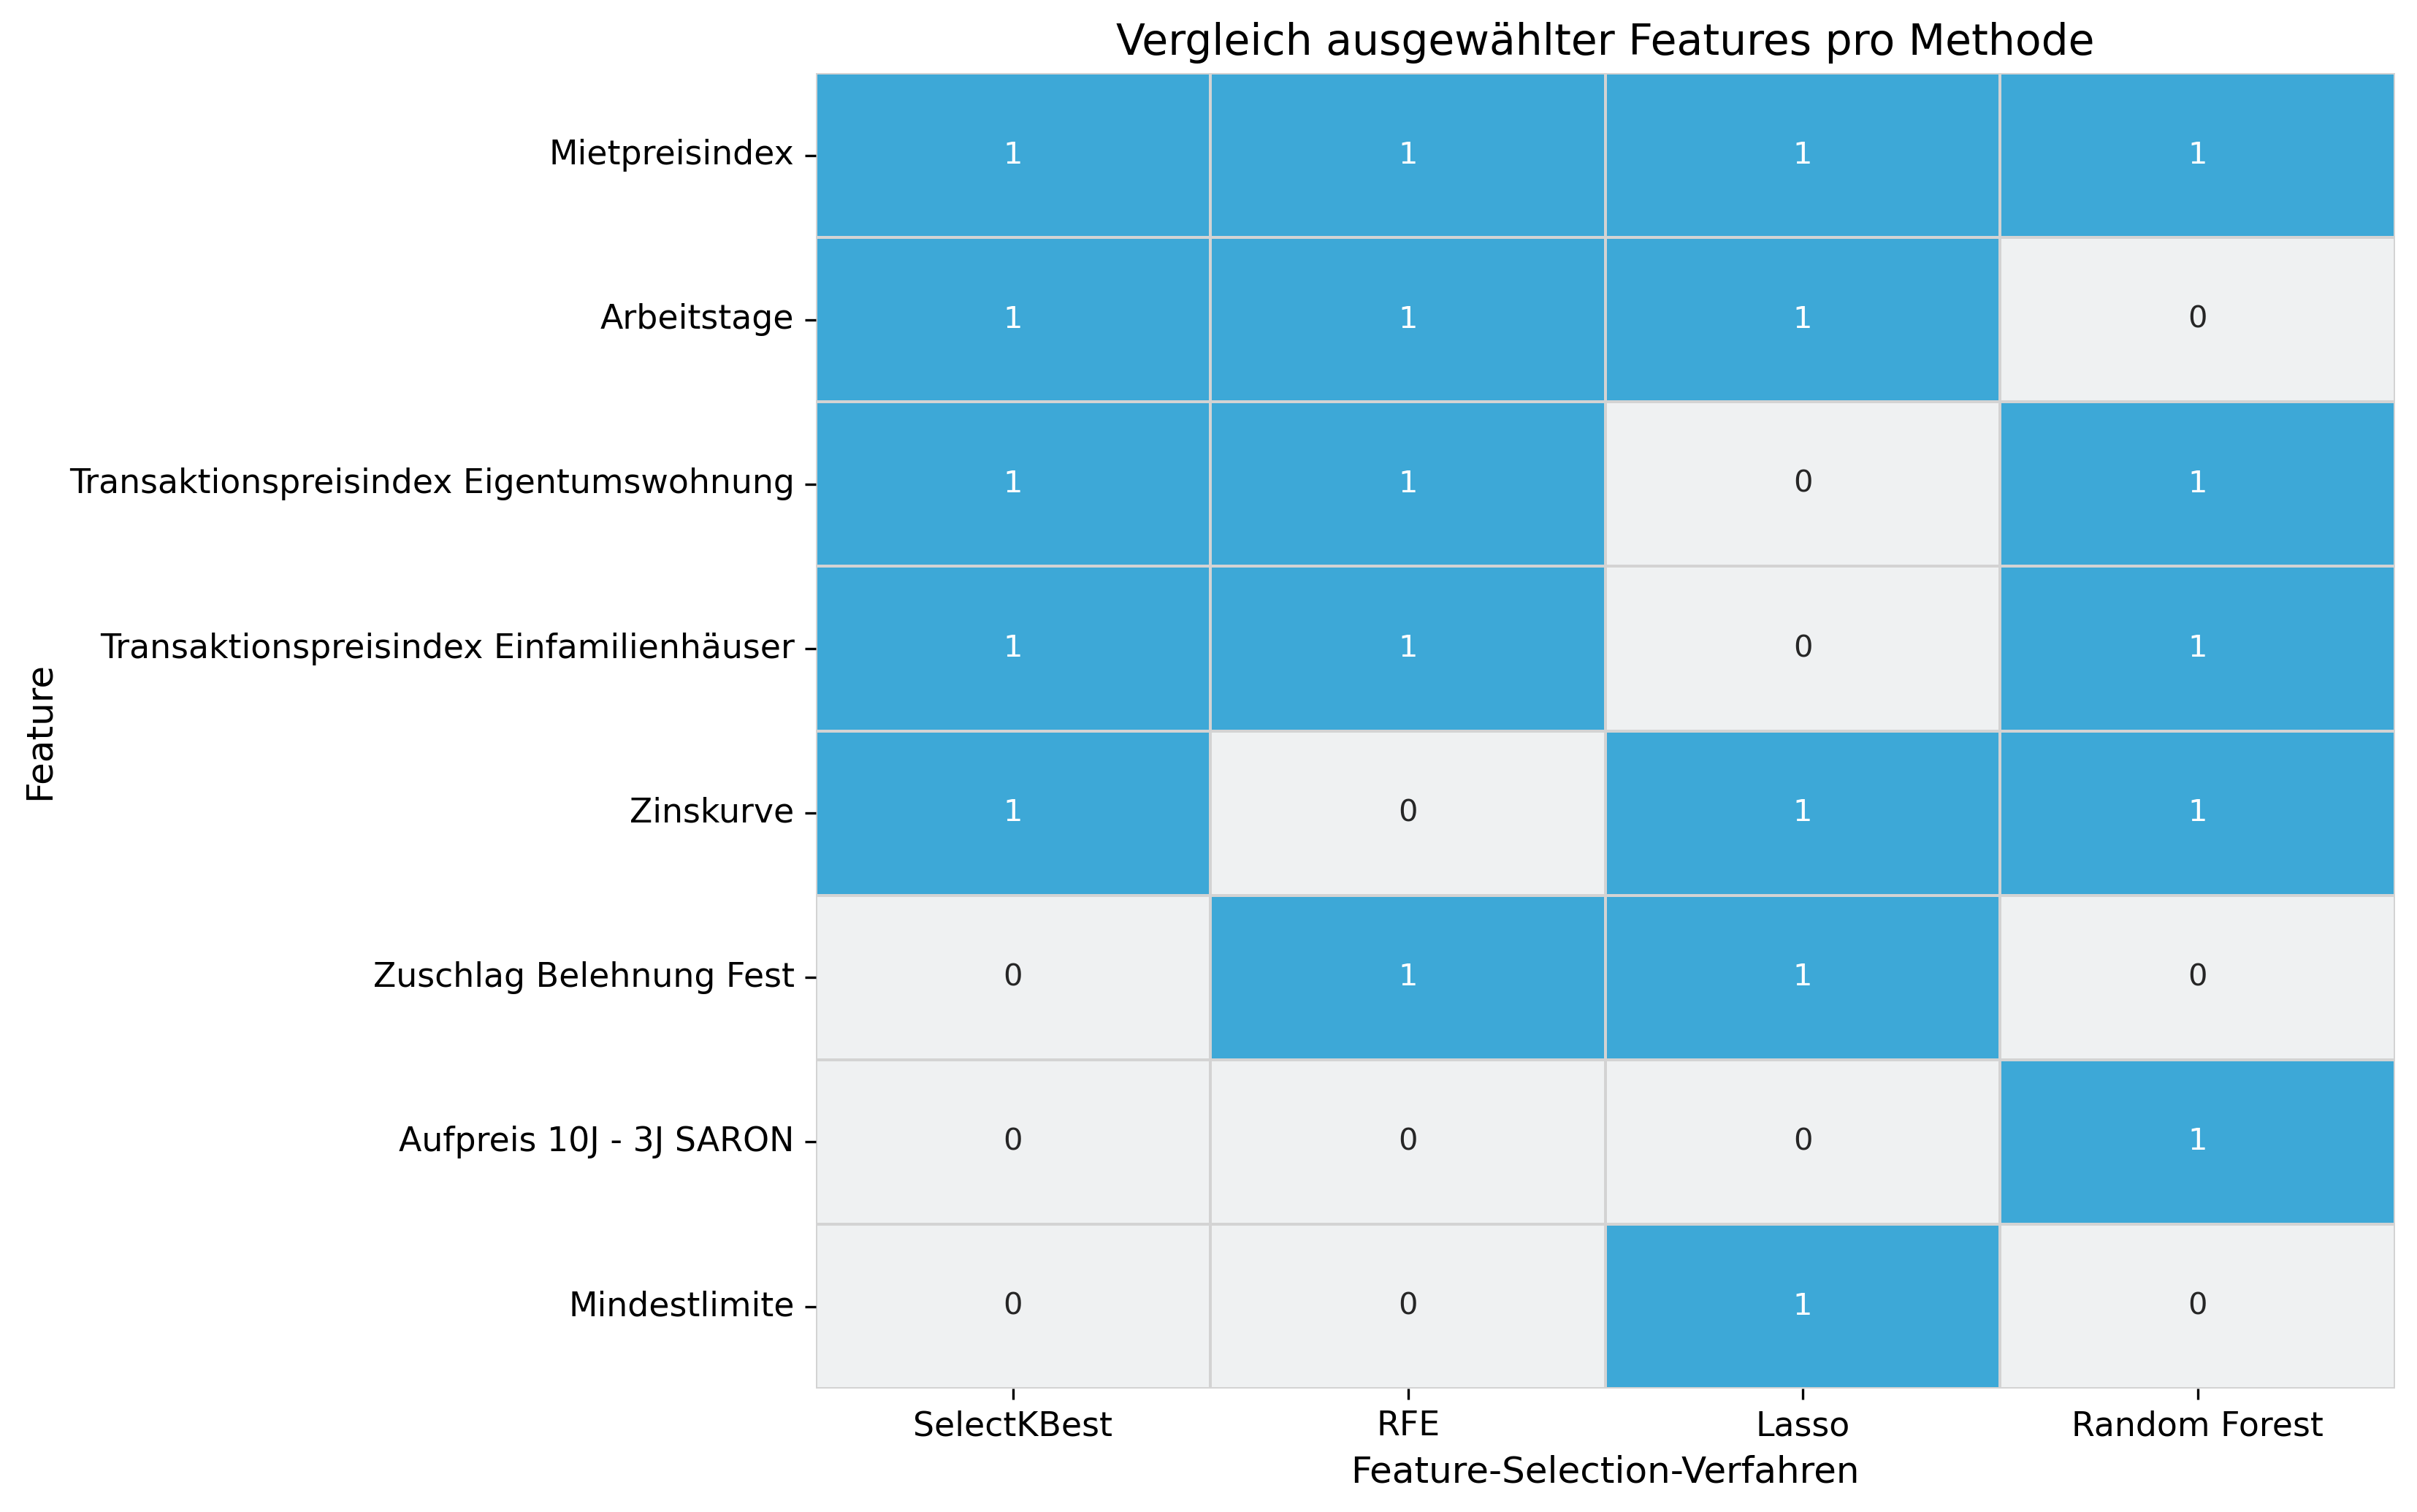

In [61]:
# Indizes der 5 besten Features (SelectKBest)
selected_features_univariate = selector.get_support(indices=True)
selected_features_selectkbest = [feature_names[i] for i in selected_features_univariate]

# Übersicht der ausgewählten Features je Verfahren
all_selected = {
    "SelectKBest": selected_features_selectkbest,
    "RFE": rfe_ranking[rfe_ranking == 1].index.tolist(),
    "Lasso": lasso_coefs_nonzero.abs().sort_values(ascending=False).head(5).index.tolist(),
    "Random Forest": rf_importances.sort_values(ascending=False).head(5).index.tolist()
}

# Alle Features, die mindestens in einem Verfahren ausgewählt wurden
all_features = sorted(set(feature for feature_list in all_selected.values() for feature in feature_list))

# Binär-Matrix erstellen
selection_matrix = pd.DataFrame(0, index=all_features, columns=all_selected.keys())
for method, features in all_selected.items():
    selection_matrix.loc[features, method] = 1

# Nach Häufigkeit der Auswahl sortieren
selection_matrix["Summe"] = selection_matrix.sum(axis=1)
selection_matrix = selection_matrix.sort_values("Summe", ascending=False).drop(columns="Summe")

# Heatmap erstellen
title = "Vergleich ausgewählter Features pro Methode"
fig = plt.figure(figsize=(11.13, 7), dpi=dpi)
ax = sns.heatmap(
    selection_matrix,
    annot=True,
    cmap=sns.light_palette(blue_color, as_cmap=True),
    cbar=False,
    linewidths=0.5,
    linecolor=default_color,
    fmt='d',
    annot_kws={"fontsize": 10}
)

# Achsentitel & Layout
plt.title(title, fontsize=14)
plt.xlabel("Feature-Selection-Verfahren", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Speichern & Anzeigen
save_plot(fig, title)
plt.show()
